In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import seaborn as sns

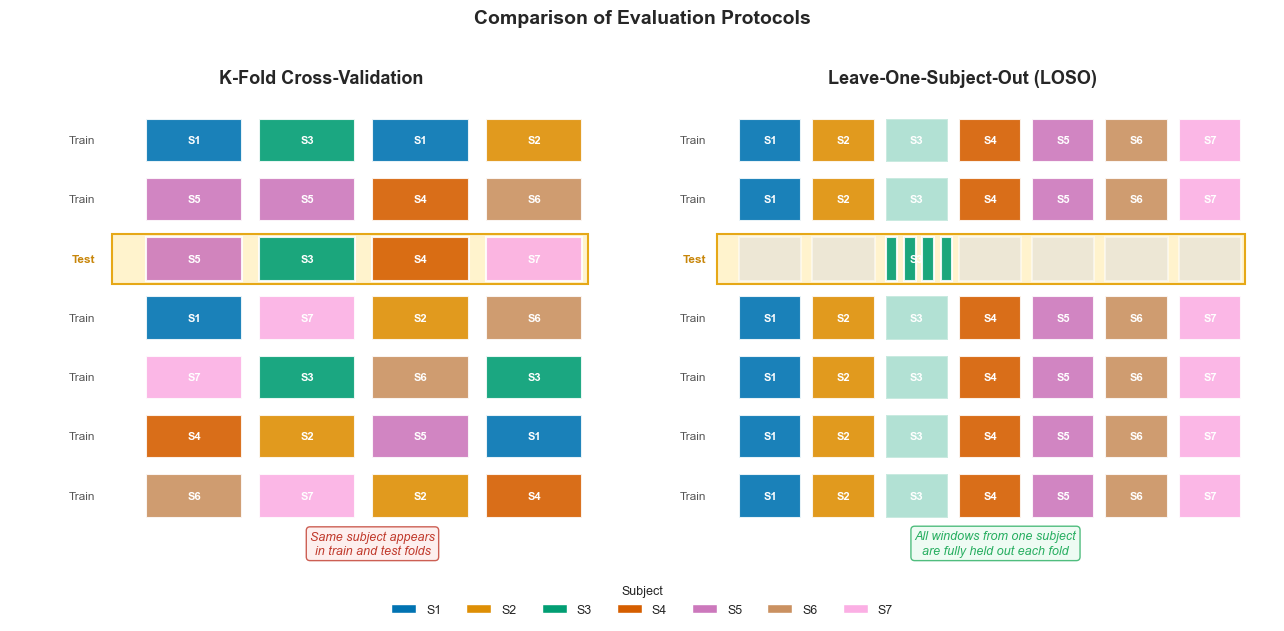

Saved


In [ ]:
n_subjects = 7
windows_per_subject = 4
n_folds = 7  

palette = sns.color_palette("colorblind", n_colors=n_subjects)

subject_labels = [f'S{i+1}' for i in range(n_subjects)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.patch.set_facecolor('white')

rect_w = 0.85
rect_h = 0.6
x_gap = 0.15
y_gap = 0.22

ax1.set_title('K-Fold Cross-Validation', fontsize=13, fontweight='bold', pad=14)

np.random.seed(7)
all_windows = []
for s in range(n_subjects):
    all_windows.extend([s] * windows_per_subject)
all_windows = np.array(all_windows)
np.random.shuffle(all_windows)

windows_per_fold = len(all_windows) // n_folds
highlight_fold = 2  

for fold_idx in range(n_folds):
    fold_windows = all_windows[fold_idx * windows_per_fold:(fold_idx + 1) * windows_per_fold]
    is_test = (fold_idx == highlight_fold)
    y_pos = (n_folds - fold_idx - 1) * (rect_h + y_gap)


    if is_test:
        bg = plt.Rectangle((-0.3, y_pos - 0.05),
                            windows_per_fold * (rect_w + x_gap) + 0.2,
                            rect_h + 0.1,
                            facecolor='#fff3cd', edgecolor='#e6a817',
                            linewidth=1.5, zorder=0)
        ax1.add_patch(bg)

    for win_idx, subj in enumerate(fold_windows):
        x_pos = win_idx * (rect_w + x_gap)
        rect = plt.Rectangle((x_pos, y_pos), rect_w, rect_h,
                              facecolor=palette[subj],
                              edgecolor='white', linewidth=1.5,
                              alpha=0.9, zorder=1)
        ax1.add_patch(rect)
        ax1.text(x_pos + rect_w / 2, y_pos + rect_h / 2,
                 subject_labels[subj],
                 ha='center', va='center',
                 fontsize=8, fontweight='bold', color='white', zorder=2)


    label = 'Test' if is_test else 'Train'
    color = '#c8860a' if is_test else '#555555'
    ax1.text(-0.45, y_pos + rect_h / 2, label,
             ha='right', va='center', fontsize=8.5,
             color=color, fontweight='bold' if is_test else 'normal')

total_width = windows_per_fold * (rect_w + x_gap)
total_height = n_folds * (rect_h + y_gap)

# Leakage annotation
ax1.annotate('Same subject appears\nin train and test folds',
             xy=(total_width * 0.5, -0.5),
             fontsize=9, ha='center', color='#c0392b',
             style='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdecea',
                       edgecolor='#c0392b', alpha=0.8))

ax1.set_xlim(-1.2, total_width + 0.3)
ax1.set_ylim(-1.1, total_height)
ax1.axis('off')


ax2.set_title('Leave-One-Subject-Out (LOSO)', fontsize=13, fontweight='bold', pad=14)

highlight_subject = 2  

for fold_idx in range(n_subjects):
    y_pos = (n_subjects - fold_idx - 1) * (rect_h + y_gap)
    is_test_fold = (fold_idx == highlight_subject)

    if is_test_fold:
        bg = plt.Rectangle((-0.3, y_pos - 0.05),
                            n_subjects * (rect_w + x_gap) + 0.2,
                            rect_h + 0.1,
                            facecolor='#fff3cd', edgecolor='#e6a817',
                            linewidth=1.5, zorder=0)
        ax2.add_patch(bg)

    for subj_idx in range(n_subjects):
        x_pos = subj_idx * (rect_w + x_gap)
        is_test_subj = (subj_idx == highlight_subject)

        if is_test_fold:
            if is_test_subj:
                for w in range(windows_per_subject):
                    wx = x_pos + w * (rect_w + x_gap) / windows_per_subject
                    rect = plt.Rectangle((wx, y_pos),
                                         rect_w / windows_per_subject - 0.05,
                                         rect_h,
                                         facecolor=palette[subj_idx],
                                         edgecolor='white', linewidth=1.5,
                                         alpha=0.9, zorder=1)
                    ax2.add_patch(rect)
                ax2.text(x_pos + rect_w / 2, y_pos + rect_h / 2,
                         subject_labels[subj_idx],
                         ha='center', va='center',
                         fontsize=8, fontweight='bold', color='white', zorder=2)
            else:
                rect = plt.Rectangle((x_pos, y_pos), rect_w, rect_h,
                                     facecolor='#dddddd',
                                     edgecolor='white', linewidth=1.5,
                                     alpha=0.5, zorder=1)
                ax2.add_patch(rect)
        else:
            rect = plt.Rectangle((x_pos, y_pos), rect_w, rect_h,
                                  facecolor=palette[subj_idx],
                                  edgecolor='white', linewidth=1.5,
                                  alpha=0.9 if not is_test_subj else 0.3,
                                  zorder=1)
            ax2.add_patch(rect)
            ax2.text(x_pos + rect_w / 2, y_pos + rect_h / 2,
                     subject_labels[subj_idx],
                     ha='center', va='center',
                     fontsize=8, fontweight='bold', color='white', zorder=2)

    label = 'Test' if is_test_fold else 'Train'
    color = '#c8860a' if is_test_fold else '#555555'
    ax2.text(-0.45, y_pos + rect_h / 2, label,
             ha='right', va='center', fontsize=8.5,
             color=color, fontweight='bold' if is_test_fold else 'normal')

total_width2 = n_subjects * (rect_w + x_gap)
total_height2 = n_subjects * (rect_h + y_gap)

ax2.annotate('All windows from one subject\nare fully held out each fold',
             xy=(total_width2 * 0.5, -0.5),
             fontsize=9, ha='center', color='#27ae60',
             style='italic',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1',
                       edgecolor='#27ae60', alpha=0.8))

ax2.set_xlim(-1.2, total_width2 + 0.3)
ax2.set_ylim(-1.1, total_height2)
ax2.axis('off')

legend_patches = [mpatches.Patch(facecolor=palette[i], label=subject_labels[i],
                                  edgecolor='white')
                  for i in range(n_subjects)]
fig.legend(handles=legend_patches, loc='lower center', ncol=n_subjects,
           fontsize=9, title='Subject', title_fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Comparison of Evaluation Protocols', fontsize=14,
             fontweight='bold', y=1.01)

plt.tight_layout()
# plt.savefig('eval_protocol_diagram.pdf', dpi=300, bbox_inches='tight')
plt.savefig('eval_diagram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved")

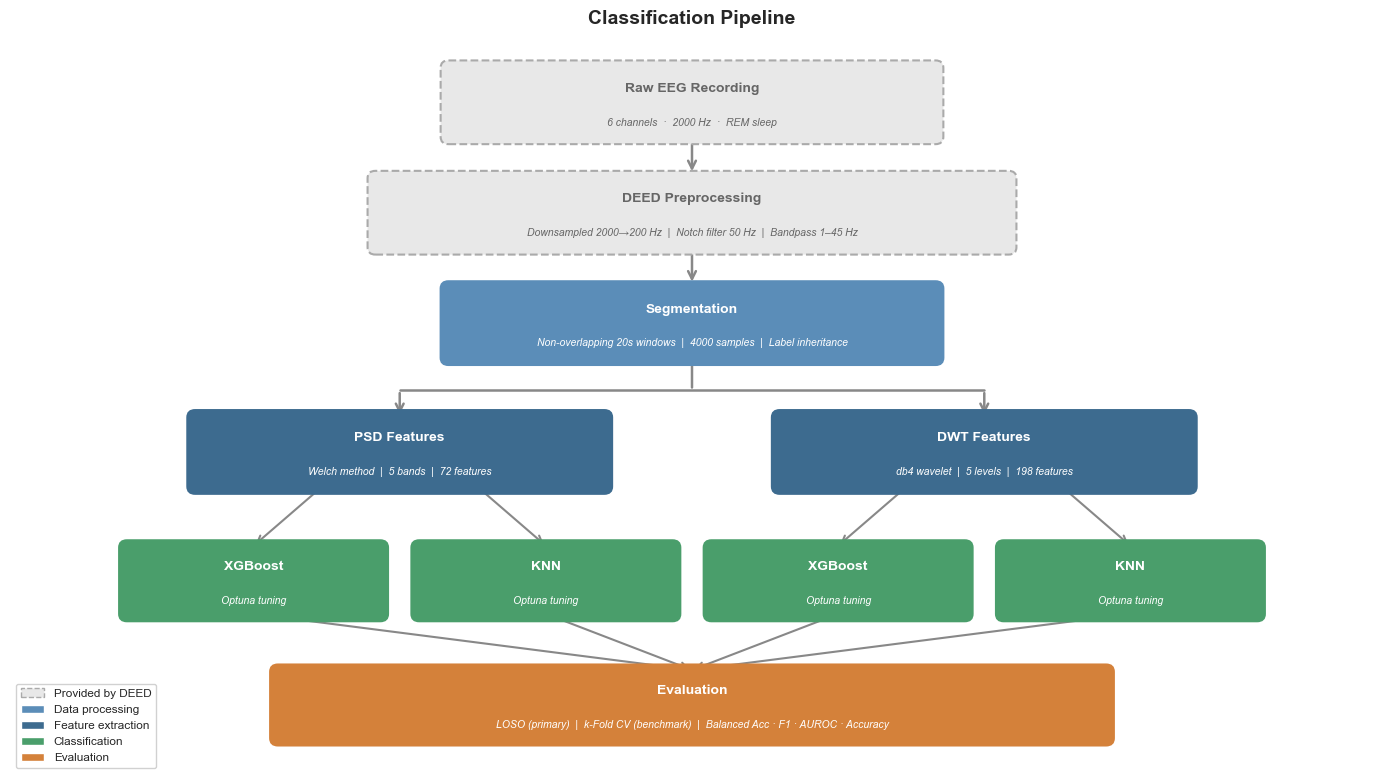

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')

def draw_box(ax, x, y, w, h, label, sublabel=None,
             facecolor='#5b8db8', textcolor='white',
             edgecolor=None, alpha=1.0, fontsize=10,
             linestyle='solid'):
    if edgecolor is None:
        edgecolor = facecolor
    rect = mpatches.FancyBboxPatch((x - w/2, y - h/2), w, h,
                                    boxstyle="round,pad=0.08",
                                    facecolor=facecolor,
                                    edgecolor=edgecolor,
                                    linewidth=1.5,
                                    alpha=alpha,
                                    linestyle=linestyle,
                                    zorder=2)
    ax.add_patch(rect)
    if sublabel:
        ax.text(x, y + 0.15, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold',
                color=textcolor, alpha=alpha, zorder=3)
        ax.text(x, y - 0.22, sublabel, ha='center', va='center',
                fontsize=7.5, color=textcolor, alpha=alpha, zorder=3,
                style='italic')
    else:
        ax.text(x, y, label, ha='center', va='center',
                fontsize=fontsize, fontweight='bold',
                color=textcolor, alpha=alpha, zorder=3)

def draw_split_arrow(ax, x_start, y_start, x_end1, y_end1, x_end2, y_end2, color='#888888'):
    ax.annotate('', xy=(x_start, y_start - 0.35), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle='-', color=color, lw=1.8), zorder=1)
    ax.plot([x_end1, x_end2], [y_start - 0.35, y_start - 0.35],
            color=color, lw=1.8, zorder=1)
    ax.annotate('', xy=(x_end1, y_end1), xytext=(x_end1, y_start - 0.35),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8, mutation_scale=14), zorder=1)
    ax.annotate('', xy=(x_end2, y_end2), xytext=(x_end2, y_start - 0.35),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8, mutation_scale=14), zorder=1)

blue       = '#5b8db8'
blue_dark  = '#3d6b8f'
green      = '#4a9e6b'
orange     = '#d4813a'
grey_face  = '#e8e8e8'
grey_edge  = '#aaaaaa'
grey_text  = '#666666'

y_raw    = 7.3
y_deed   = 6.1
y_seg    = 4.9
y_fe     = 3.5
y_model  = 2.1
y_eval   = 0.75

draw_box(ax, 7, y_raw, 5.0, 0.75,
         'Raw EEG Recording',
         sublabel='6 channels  ·  2000 Hz  ·  REM sleep',
         facecolor=grey_face, edgecolor=grey_edge, textcolor=grey_text,
         fontsize=10, linestyle='dashed')

ax.annotate('', xy=(7, y_deed + 0.42), xytext=(7, y_raw - 0.4),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.8, mutation_scale=14), zorder=1)

# ── DEED Preprocessing box ────────────────────────────────────────────────────
draw_box(ax, 7, y_deed, 6.5, 0.75,
         'DEED Preprocessing',
         sublabel='Downsampled 2000→200 Hz  |  Notch filter 50 Hz  |  Bandpass 1–45 Hz',
         facecolor=grey_face, edgecolor=grey_edge, textcolor=grey_text,
         fontsize=10, linestyle='dashed')

# ax.text(0.4, (y_raw + y_deed) / 2, 'Provided\nby DEED', ha='center', va='center',
#         fontsize=7.5, color=grey_text, style='italic')

# ── Arrow: DEED → Segmentation ────────────────────────────────────────────────
ax.annotate('', xy=(7, y_seg + 0.42), xytext=(7, y_deed - 0.4),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.8, mutation_scale=14), zorder=1)

draw_box(ax, 7, y_seg, 5.0, 0.75,
         'Segmentation',
         sublabel='Non-overlapping 20s windows  |  4000 samples  |  Label inheritance',
         facecolor=blue, textcolor='white', fontsize=10)

draw_split_arrow(ax, 7, y_seg - 0.38, 4.0, y_fe + 0.38, 10.0, y_fe + 0.38)

draw_box(ax, 4.0, y_fe, 4.2, 0.75,
         'PSD Features',
         sublabel='Welch method  |  5 bands  |  72 features',
         facecolor=blue_dark, textcolor='white', fontsize=10)

draw_box(ax, 10.0, y_fe, 4.2, 0.75,
         'DWT Features',
         sublabel='db4 wavelet  |  5 levels  |  198 features',
         facecolor=blue_dark, textcolor='white', fontsize=10)

ax.annotate('', xy=(2.5, y_model + 0.38), xytext=(3.2, y_fe - 0.38),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.5, mutation_scale=12), zorder=1)
ax.annotate('', xy=(5.5, y_model + 0.38), xytext=(4.8, y_fe - 0.38),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.5, mutation_scale=12), zorder=1)
ax.annotate('', xy=(8.5, y_model + 0.38), xytext=(9.2, y_fe - 0.38),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.5, mutation_scale=12), zorder=1)
ax.annotate('', xy=(11.5, y_model + 0.38), xytext=(10.8, y_fe - 0.38),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.5, mutation_scale=12), zorder=1)

draw_box(ax, 2.5, y_model, 2.6, 0.72, 'XGBoost',
         sublabel='Optuna tuning', facecolor=green, textcolor='white', fontsize=10)
draw_box(ax, 5.5, y_model, 2.6, 0.72, 'KNN',
         sublabel='Optuna tuning', facecolor=green, textcolor='white', fontsize=10)
draw_box(ax, 8.5, y_model, 2.6, 0.72, 'XGBoost',
         sublabel='Optuna tuning', facecolor=green, textcolor='white', fontsize=10)
draw_box(ax, 11.5, y_model, 2.6, 0.72, 'KNN',
         sublabel='Optuna tuning', facecolor=green, textcolor='white', fontsize=10)

for x in [2.5, 5.5, 8.5, 11.5]:
    ax.annotate('', xy=(7, y_eval + 0.38), xytext=(x, y_model - 0.36),
                arrowprops=dict(arrowstyle='->', color='#888888', lw=1.5, mutation_scale=12), zorder=1)

draw_box(ax, 7, y_eval, 8.5, 0.72,
         'Evaluation',
         sublabel='LOSO (primary)  |  k-Fold CV (benchmark)  |  Balanced Acc · F1 · AUROC · Accuracy',
         facecolor=orange, textcolor='white', fontsize=10)

legend_elements = [
    mpatches.Patch(facecolor=grey_face, edgecolor=grey_edge, linestyle='dashed', label='Provided by DEED'),
    mpatches.Patch(facecolor=blue, label='Data processing'),
    mpatches.Patch(facecolor=blue_dark, label='Feature extraction'),
    mpatches.Patch(facecolor=green, label='Classification'),
    mpatches.Patch(facecolor=orange, label='Evaluation'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8.5,
          frameon=True, framealpha=0.9, edgecolor='#cccccc',
          bbox_to_anchor=(0.0, 0.0))

ax.set_title('Classification Pipeline', fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
# plt.savefig('pipeline_flowchart.pdf', dpi=300, bbox_inches='tight')
plt.savefig('pipeline_flowchart.png', dpi=300, bbox_inches='tight')
plt.show()